In [2]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import pandas as pd
import cv2

HOG_SIZE = 64
CLASS_NAMES = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']



In [3]:
model = joblib.load("hog_svm_baseline.pkl") 
candidatas = pd.read_csv("../candidatas_finales_comunes.csv")

def get_hog_visualization(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face = cv2.resize(gray, (HOG_SIZE, HOG_SIZE))
    face_norm = face / 255.0

    features, hog_image = hog(
        face_norm,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True
    )
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    return face, hog_image_rescaled, features

def predecir_hog_svm(model, features):
    pred = model.predict([features])[0]
    return CLASS_NAMES[pred]

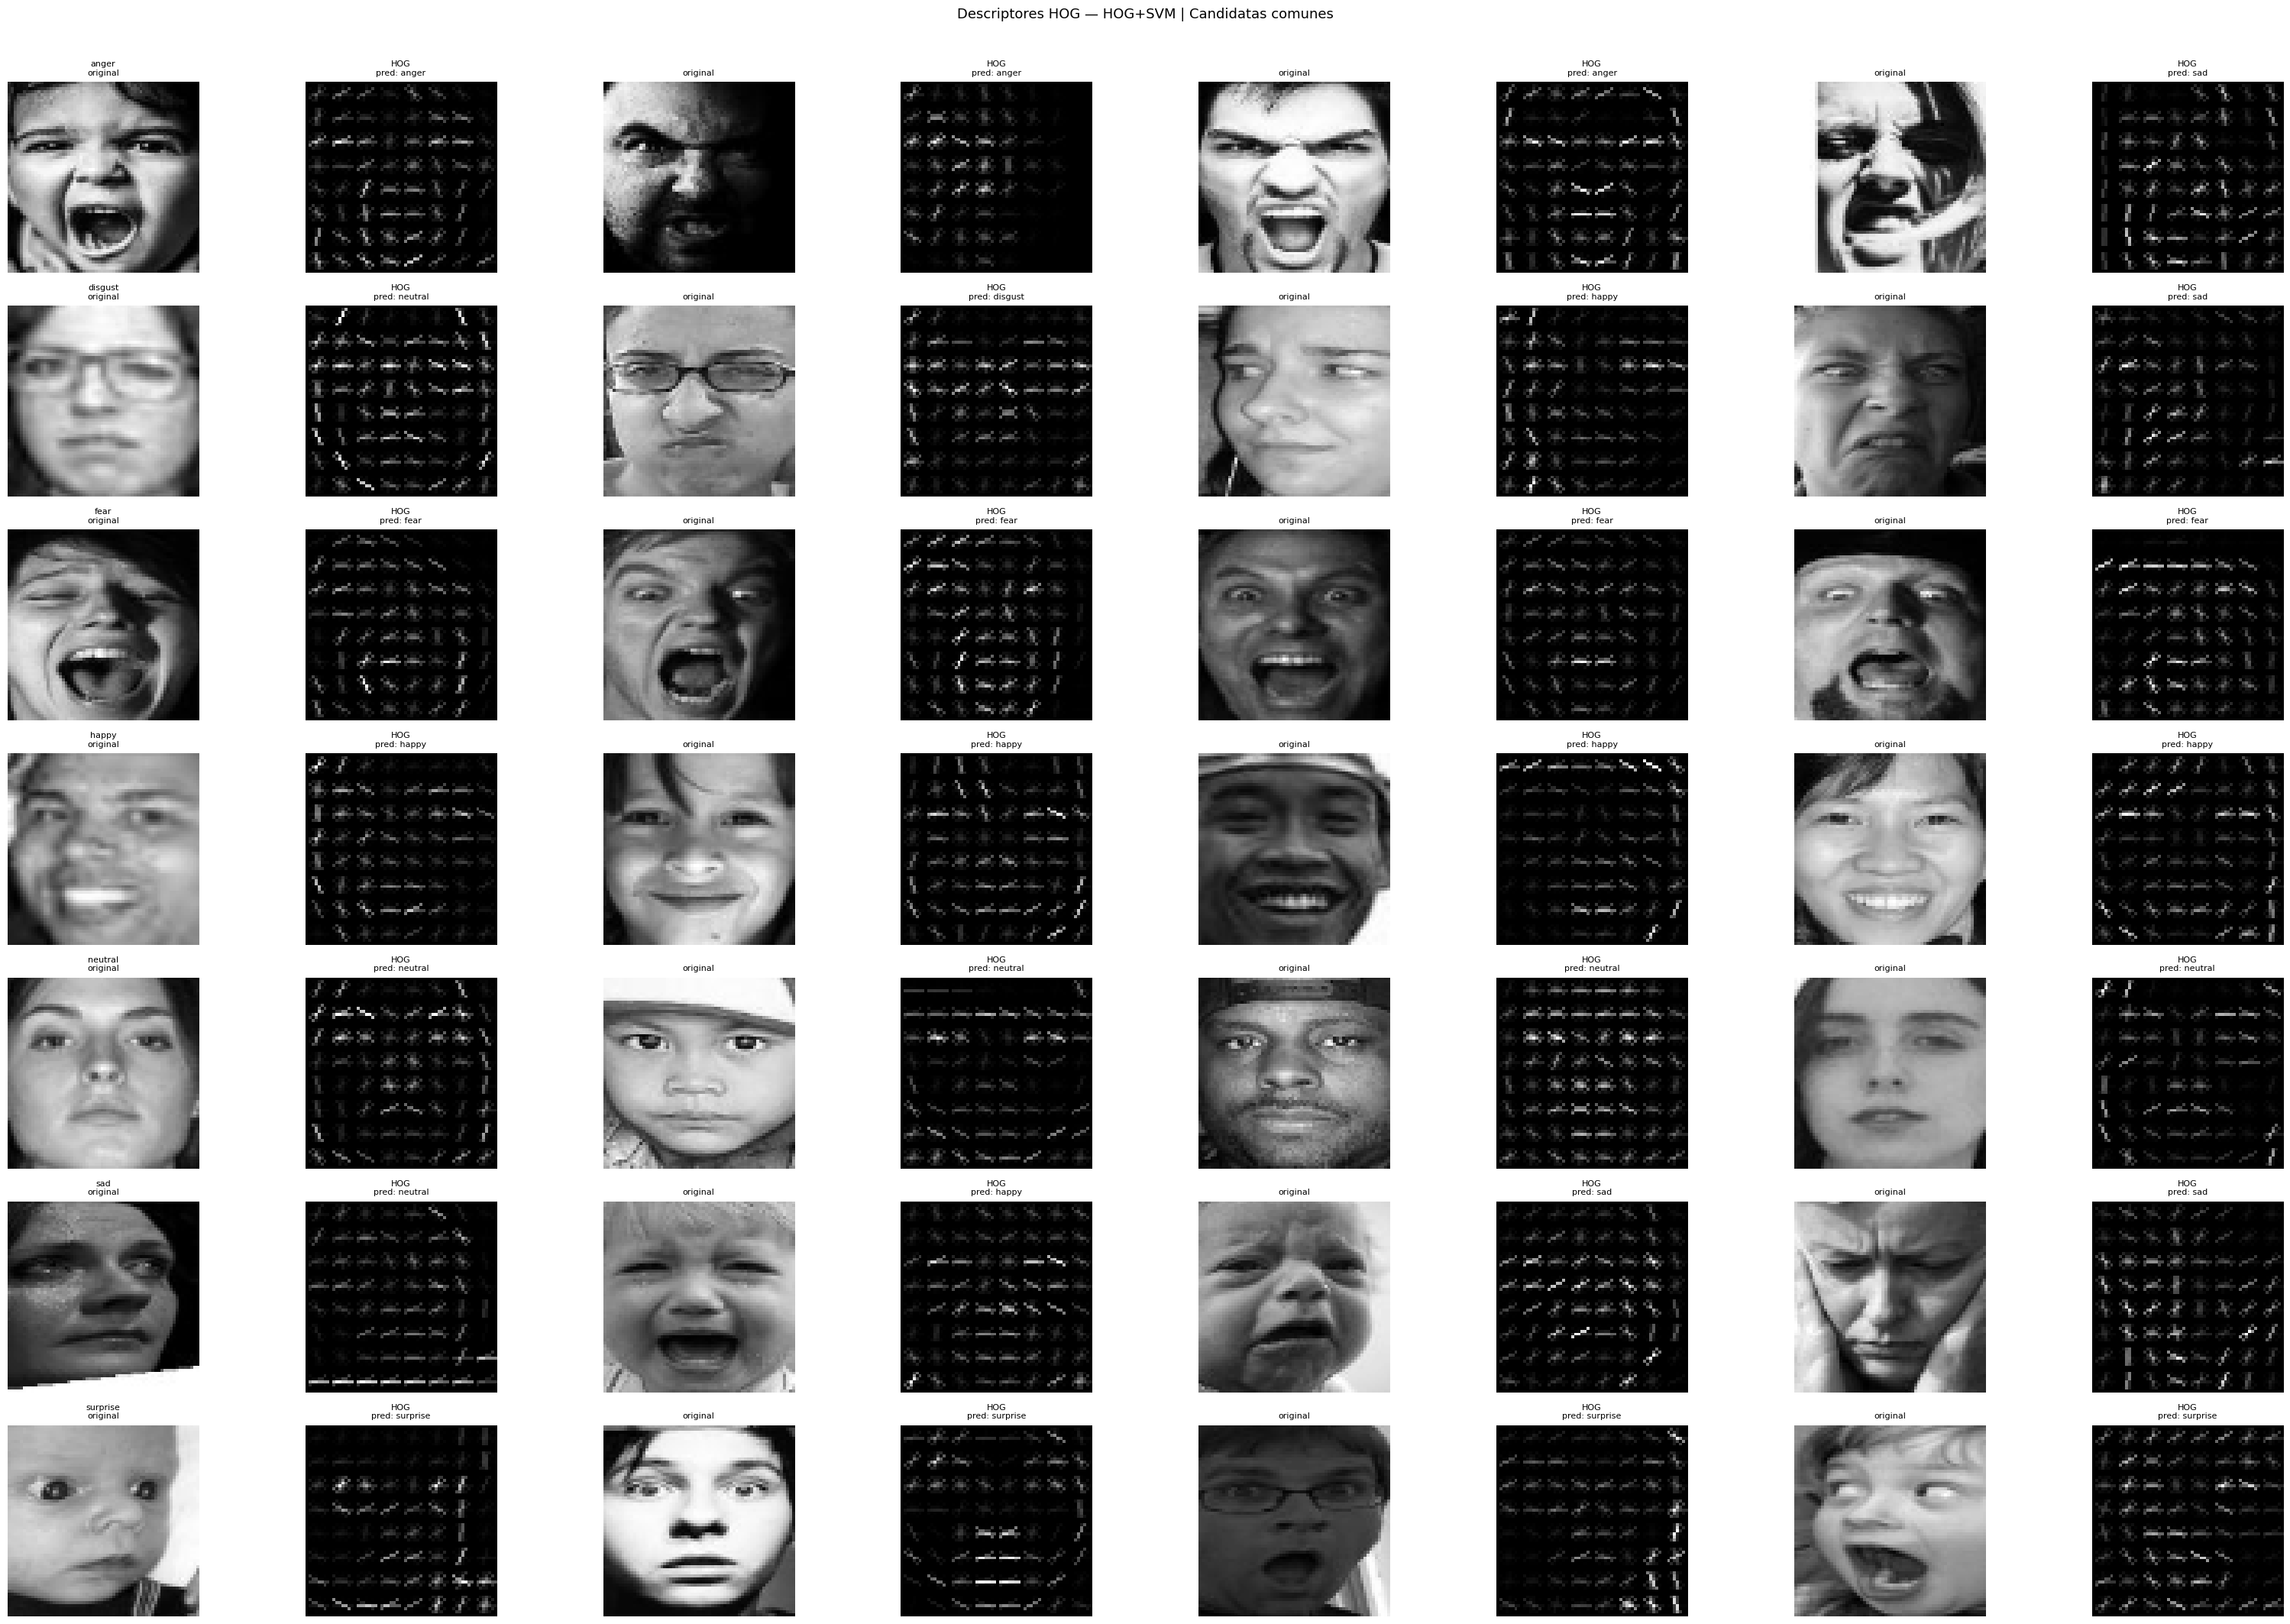

In [3]:
fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=8,  # 4 imágenes × (original + HOG)
    figsize=(32, len(CLASS_NAMES) * 3)
)

for row_idx, emotion_idx in enumerate(range(len(CLASS_NAMES))):
    emotion_name = CLASS_NAMES[emotion_idx]
    subset = candidatas[candidatas["label_real"] == emotion_idx]

    for col_pair, (_, row) in enumerate(subset.iterrows()):
        if col_pair >= 4:
            break

        face, hog_img, features = get_hog_visualization(row["imagen_path"])
        pred = predecir_hog_svm(model, features)

        col_orig = col_pair * 2
        col_hog  = col_pair * 2 + 1

        axes[row_idx, col_orig].imshow(face, cmap="gray")
        axes[row_idx, col_orig].axis("off")
        if col_pair == 0:
            axes[row_idx, col_orig].set_title(f"{emotion_name}\noriginal", fontsize=8)
        else:
            axes[row_idx, col_orig].set_title("original", fontsize=8)

        axes[row_idx, col_hog].imshow(hog_img, cmap="gray")
        axes[row_idx, col_hog].axis("off")
        axes[row_idx, col_hog].set_title(f"HOG\npred: {pred}", fontsize=8)

plt.suptitle("Descriptores HOG — HOG+SVM | Candidatas comunes", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("hog_explicabilidad.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import time
import numpy as np
import cv2
from skimage.feature import hog

N_RUNS   = 100
N_WARMUP = 10

img = cv2.imread(candidatas["imagen_path"].iloc[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face = cv2.resize(gray, (HOG_SIZE, HOG_SIZE))
face_norm = face / 255.0

def extract_hog(img_norm):
    return hog(
        img_norm,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False
    )

def predict_fn(img_norm):
    features = extract_hog(img_norm)
    return model.predict([features])[0]

times       = []
times_hog   = []
times_svm   = []

for _ in range(N_WARMUP):
    predict_fn(face_norm)

for _ in range(N_RUNS):

    predict_fn(face_norm)  
    start = time.perf_counter()

    t0 = time.perf_counter()
    features = extract_hog(face_norm)
    t1 = time.perf_counter()
    _ = model.predict([features])[0]
    t2 = time.perf_counter()

    times_hog.append((t1 - t0) * 1000)
    times_svm.append((t2 - t1) * 1000)
    times.append((t2 - start) * 1000)

times     = np.array(times)
times_hog = np.array(times_hog)
times_svm = np.array(times_svm)

print("── Pipeline completo (HOG + SVM) ──────────────")
print(f"Latencia media:      {np.mean(times):.3f} ms")
print(f"Desviación estándar: {np.std(times):.3f} ms")
print(f"Mediana (p50):       {np.percentile(times, 50):.3f} ms")
print(f"P95:                 {np.percentile(times, 95):.3f} ms")
print(f"P99:                 {np.percentile(times, 99):.3f} ms")

print("\n── Desglose ───────────────────────────────────")
print(f"Extracción HOG: {np.mean(times_hog):.3f} ms  ({np.mean(times_hog)/np.mean(times)*100:.1f}%)")
print(f"Predicción SVM: {np.mean(times_svm):.3f} ms  ({np.mean(times_svm)/np.mean(times)*100:.1f}%)")

── Pipeline completo (HOG + SVM) ──────────────
Latencia media:      15.062 ms
Desviación estándar: 0.351 ms
Mediana (p50):       15.022 ms
P95:                 15.475 ms
P99:                 15.805 ms

── Desglose ───────────────────────────────────
Extracción HOG: 0.993 ms  (6.6%)
Predicción SVM: 14.069 ms  (93.4%)
